# Hockey Statistics - HC Verva Litvínov in Czech hockey league

- This notebook analyzes match data for HC Verva Litvínov across multiple Czech Extraliga seasons.
- The main goal is to compare team performance over time, analyze results against individual opponents, and explore scoring patterns using Python.
- The source dataset was prepared in Excel and Power Query based on data from hokej.cz.

## Preparing dataset

- importing data from dataset (Excel file "Statistiky", sheet name "ZapasyLIT")
- there are many columns like type of round, name of opponent, if is match played home or away, goals, points, standing, scorers, etc.
- dataset is made in Czech language, so names of columns and content is in Czech
- adding new columns (goals in each periods of matches)

In [24]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
litvinov_df = pd.read_excel("Statistiky.xlsx", sheet_name="ZapasyLIT", index_col=3)
# Data in Excel file - it contains hockey matches statistics of HC Verva Litvínov from Czech Republic, there are matches from season 2018/2019

In [26]:
litvinov_df.columns
# List of column names

Index(['Sezóna', 'Odehr. z.', 'Kolo', 'Soupeř', 'Doma/venku',
       'Výsledek pro LIT', 'Výsledek', 'Góly LIT', 'Góly soupeř',
       'G LIT 60(BEZ EN)', 'G Soupeř 60(BEZ EN)', 'Umístění LIT',
       'Tabulka pravdy', 'Bodů celkově', 'Góly v přesilovce',
       'Góly v oslabení', 'Góly inkas. v přesilovce', 'Góly inkas. v oslabení',
       'Počet přesilovek', 'Počet oslabení', 'Počet diváků', '1. třetina',
       '2. třetina', '3. třetina', 'Prodl./Náj.', 'Průběh zápasu', '1. gól',
       '2. gól', '3. gól', '4. gól', '5. gól', '6. gól', '7. gól', '8. gól',
       'Nájezdy', 'Sestava', '1. gól – střelec', '2. gól – střelec',
       '3. gól – střelec', '4. gól – střelec', '5. gól – střelec',
       '6. gól – střelec', '7. gól – střelec', '8. gól – střelec',
       'Góly LIT první třetina', 'Góly soupeř první třetina',
       'Góly LIT druhá třetina', 'Góly soupeř druhá třetina',
       'Góly LIT třetí třetina', 'Góly soupeř třetí třetina', 'Rozdíl skóre',
       'Body v zápase'],
     

In [25]:
opponents = litvinov_df["Soupeř"].unique()
print(opponents)
# List of all Litvínov´s opponents

['Ml.Boleslav' 'Zlín' 'Pardubice' 'Chomutov' 'Energie KV' 'Olomouc'
 'Třinec' 'Mountfield HK' 'Kometa Brno' 'Liberec' 'Sparta' 'Plzeň'
 'Vítkovice' 'Kladno' 'Motor ČB']


In [39]:
litvinov_df[["Góly LIT první třetina", "Góly soupeř první třetina"]] = \
    litvinov_df["1. třetina"].str.split(":", expand=True)

litvinov_df["Góly LIT první třetina"] = \
    litvinov_df["Góly LIT první třetina"].astype(int)

litvinov_df["Góly soupeř první třetina"] = \
    litvinov_df["Góly soupeř první třetina"].astype(int)

litvinov_df[["Góly LIT druhá třetina", "Góly soupeř druhá třetina"]] = \
    litvinov_df["2. třetina"].str.split(":", expand=True)

litvinov_df["Góly LIT druhá třetina"] = \
    litvinov_df["Góly LIT druhá třetina"].astype(int)

litvinov_df["Góly soupeř druhá třetina"] = \
    litvinov_df["Góly soupeř druhá třetina"].astype(int)

litvinov_df[["Góly LIT třetí třetina", "Góly soupeř třetí třetina"]] = \
    litvinov_df["3. třetina"].str.split(":", expand=True)

litvinov_df["Góly LIT třetí třetina"] = \
    litvinov_df["Góly LIT třetí třetina"].astype(int)

litvinov_df["Góly soupeř třetí třetina"] = \
    litvinov_df["Góly soupeř třetí třetina"].astype(int)

litvinov_df["Góly LIT"] = \
    litvinov_df["Góly LIT"].astype(int)

litvinov_df["Góly soupeř"] = \
    litvinov_df["Góly soupeř"].astype(int)

litvinov_df["Rozdíl skóre"] = (litvinov_df["Góly LIT"] - litvinov_df["Góly soupeř"])

kolo_num = pd.to_numeric(litvinov_df["Kolo"], errors="coerce")

litvinov_df["Body v zápase"] = np.where(
    kolo_num.between(1, 60),
    litvinov_df["Výsledek"].map({
        "V": 3,
        "VP": 2,
        "PP": 1,
        "P": 0
    }),
    np.nan
)
litvinov_df["Body v zápase"] = litvinov_df["Body v zápase"].astype("Int64")
# Creating of calculated columns - goals for each match period and points from each match for Litvínov


In [34]:
seasons = litvinov_df["Sezóna"].unique()
print(seasons)
# List of all seasons

['Sezóna 18/19' 'Sezóna 19/20' 'Sezóna 20/21' 'Sezóna 21/22'
 'Sezóna 22/23' 'Sezóna 23/24' 'Sezóna 24/25' 'Sezóna 25/26']


## Exporting data

- In this section, I prepare two output datasets for further SQL work in PostgreSQL.
- The exported files are formatted to match my import workflow, including export without column headers.

In [40]:
export_to_csv = litvinov_df[["Sezóna", "Odehr. z.", "Kolo", "Soupeř", "Doma/venku", "Výsledek pro LIT", "Výsledek", "Góly LIT", "Góly soupeř", "Rozdíl skóre", "1. třetina", "Góly LIT první třetina", "Góly soupeř první třetina", "2. třetina", "Góly LIT druhá třetina", "Góly soupeř druhá třetina", "3. třetina", "Góly LIT třetí třetina", "Góly soupeř třetí třetina", "Body v zápase"]]
# Selecting of columns to export to csv

In [41]:
export_to_csv.to_csv("litvinov_matches.csv", index=False, header=False, encoding="utf-8")
# Exporting of data to csv file

In [42]:
export_to_csv

,Sezóna,Odehr. z.,Kolo,Soupeř,Doma/venku,Výsledek pro LIT,Výsledek,Góly LIT,Góly soupeř,Rozdíl skóre,1. třetina,Góly LIT první třetina,Góly soupeř první třetina,2. třetina,Góly LIT druhá třetina,Góly soupeř druhá třetina,3. třetina,Góly LIT třetí třetina,Góly soupeř třetí třetina,Body v zápase
Datum,,,,,,,,,,,,,,,,,,,,
2018-09-14,Sezóna 18/19,1,1,Ml.Boleslav,V,4:3,V,4,3,1,2:1,2,1,2:2,2,2,0:0,0,0,3
2018-09-16,Sezóna 18/19,2,2,Zlín,D,5:2,V,5,2,3,2:0,2,0,1:1,1,1,2:1,2,1,3
2018-09-21,Sezóna 18/19,3,3,Pardubice,V,6:2,V,6,2,4,3:0,3,0,1:0,1,0,2:2,2,2,3
2018-09-23,Sezóna 18/19,4,4,Chomutov,D,4:1,V,4,1,3,1:0,1,0,2:1,2,1,1:0,1,0,3
2018-09-28,Sezóna 18/19,5,5,Energie KV,V,4:3pp,VP,4,3,1,1:1,1,1,0:2,0,2,2:0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-25,Sezóna 25/26,48,48,Motor ČB,V,2:4,P,2,4,-2,1:1,1,1,0:2,0,2,1:1,1,1,0
2026-02-27,Sezóna 25/26,49,49,Pardubice,D,1:4,P,1,4,-3,0:0,0,0,0:2,0,2,1:2,1,2,0
2026-03-01,Sezóna 25/26,50,50,Plzeň,V,2:3,P,2,3,-1,1:1,1,1,0:0,0,0,1:2,1,2,0


In [44]:
matches_scorers = litvinov_df[litvinov_df["Sezóna"] == "Sezóna 25/26"][
    ["Odehr. z.", "Soupeř", "1. gól – střelec", "2. gól – střelec", "3. gól – střelec",
     "4. gól – střelec", "5. gól – střelec", "6. gól – střelec",
     "7. gól – střelec", "8. gól – střelec"]
]
matches_scorers.to_csv("scorers_matches.csv", index=False, header=False, encoding="utf-8")

matches_scorers
# Exporting of scorers data to csv file to next analyses (Power BI, SQL, ...)

,Odehr. z.,Soupeř,1. gól – střelec,2. gól – střelec,3. gól – střelec,4. gól – střelec,5. gól – střelec,6. gól – střelec,7. gól – střelec,8. gól – střelec
Datum,,,,,,,,,,
2025-09-10,1,Kometa Brno,Matúš SUKEĽ,Adam POLÁŠEK,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-12,2,Energie KV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-14,3,Vítkovice,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-16,4,Liberec,Michal GUT,Axel HOLMSTRÖM,Theodor PIŠTĚK,Maxim ČAJKOVIČ,NaN,NaN,NaN,NaN
2025-09-19,5,Sparta,Michal PLUTNAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-23,6,Ml.Boleslav,Josef JÍCHA,Theodor PIŠTĚK,Theodor PIŠTĚK,Jaroslav BROŽ,NaN,NaN,NaN,NaN
2025-09-26,7,Mountfield HK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-28,8,Motor ČB,Michal GUT,Markus HÄNNIKÄINEN,Kevin CZUCZMAN,NaN,NaN,NaN,NaN,NaN
2025-09-30,9,Pardubice,Nicolas HLAVA,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Season performance analyses

In [31]:
results_unique = litvinov_df["Výsledek pro LIT"].unique()
results_unique
# Printing of all unique Litvínov´s matches results

array(['4:3', '5:2', '6:2', '4:1', '4:3pp', '2:1', '0:2', '1:3', '0:5',
       '1:4', '1:0', '0:3', '2:5', '3:4', '2:1pp', '7:2', '2:4', '2:3',
       '1:2sn', '3:0', '5:3', '3:2', '0:1', '1:2', '1:7', '5:1', '0:4',
       '2:1sn', '5:4pp', '6:3', '3:5', '1:5', '4:2', '3:6', '4:5', '6:5',
       '3:4pp', '4:5pp', '3:2pp', '3:4sn', '1:6', '2:6', '6:4', '4:3sn',
       '4:8', '2:3pp', '2:3sn', '5:4sn', '4:0', '3:2sn', '1:0pp', '2:0',
       '6:7sn', '5:0', '1:2pp', '3:1', '7:3', '4:7', '4:6', '6:1',
       '5:6pp', '0:1sn', '8:1', '1:0sn', '7:4', '3:8', '5:4', '5:6',
       '6:0', '2:8', '2:7', '1:8'], dtype=object)

In [32]:
result_count = litvinov_df.groupby("Výsledek pro LIT")["Kolo"].count().sort_values(ascending=False)
result_count
# Printing of all unique Litvínov´s matches results count

Výsledek pro LIT
1:3      28
3:2      22
2:3      21
1:4      21
4:1      15
         ..
5:4       1
1:0sn     1
1:8       1
1:7       1
8:1       1
Name: Kolo, Length: 72, dtype: int64

In [33]:
result_count = litvinov_df.groupby("Výsledek pro LIT")["Kolo"].count().sort_values(ascending=False)
result_count
# Printing of all unique Litvínov´s matches results count

Výsledek pro LIT
1:3      28
3:2      22
2:3      21
1:4      21
4:1      15
         ..
5:4       1
1:0sn     1
1:8       1
1:7       1
8:1       1
Name: Kolo, Length: 72, dtype: int64

In [90]:
result_count = litvinov_df.groupby(["Výsledek pro LIT", "Doma/venku"])["Kolo"].count().sort_values(ascending=False).unstack(fill_value=0)
result_count.head(20)
# Printing of all unique Litvínov´s matches results count

Doma/venku,D,Open air Dresden,V
Výsledek pro LIT,,,
0:1,1,0,4
0:1sn,1,0,0
0:2,4,0,8
0:3,3,0,11
0:4,3,0,0
0:5,2,0,2
1:0,5,0,1
1:0pp,1,0,0
1:0sn,1,0,0


In [35]:
standing_avg = litvinov_df.groupby("Sezóna")["Umístění LIT"].mean().sort_values(ascending=True)
standing_avg
# Average final standing of Litvínov in each regular season

Sezóna
Sezóna 24/25     2.384615
Sezóna 23/24     4.076923
Sezóna 18/19     7.844828
Sezóna 20/21    11.019231
Sezóna 21/22    11.517857
Sezóna 19/20    12.173077
Sezóna 22/23    12.230769
Sezóna 25/26    13.730769
Name: Umístění LIT, dtype: float64

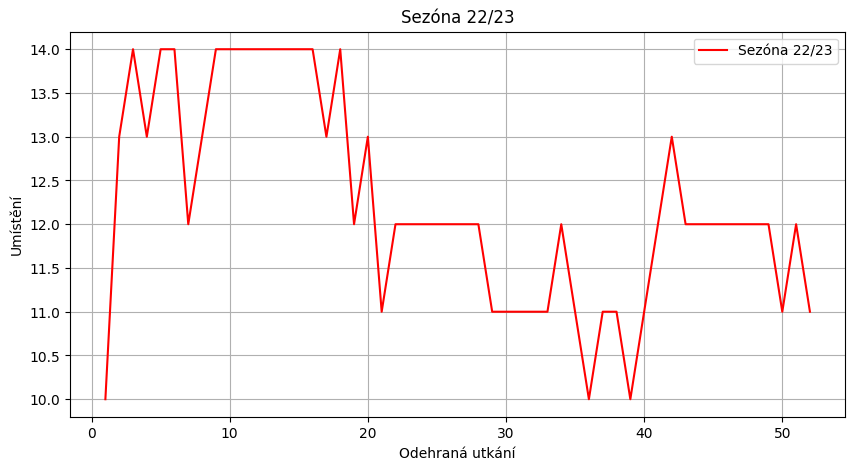

In [36]:
choice_season = litvinov_df[litvinov_df["Sezóna"] == "Sezóna 22/23"]

number_matches = choice_season["Odehr. z."].tolist()
standing = choice_season["Umístění LIT"].tolist()

plt.figure(figsize=(10,5))

plt.plot(number_matches, standing, label="Sezóna 22/23", color="red")

plt.title("Sezóna 22/23")
plt.xlabel("Odehraná utkání")
plt.ylabel("Umístění")

plt.legend()
plt.grid(True)

plt.savefig("pic.png")
plt.show()

# Standing of HC Verva Litvínov in selected season

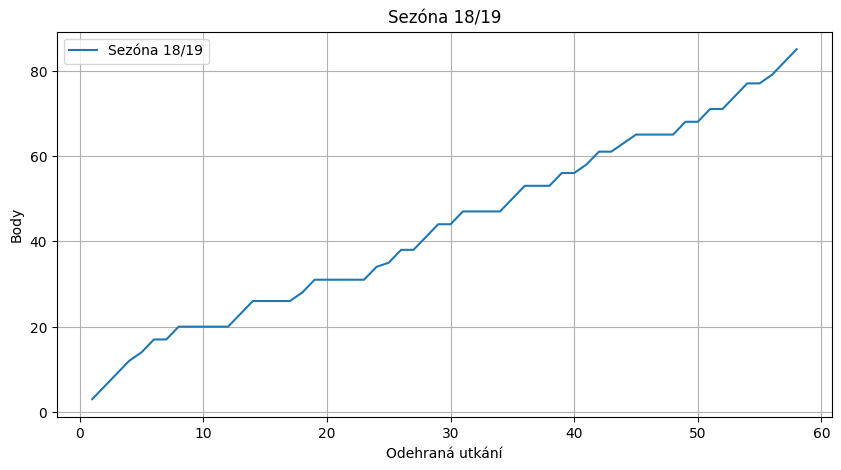

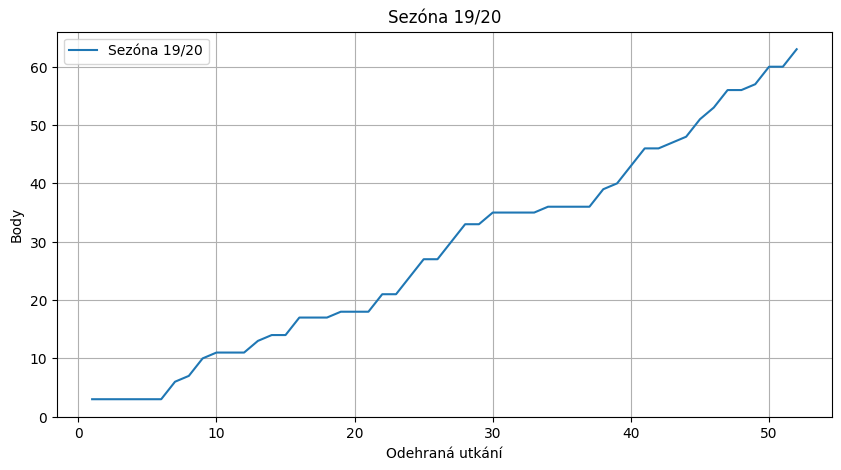

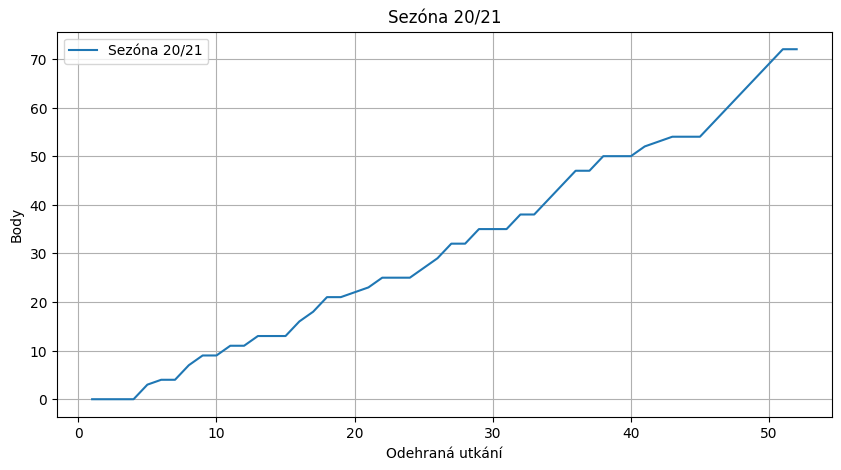

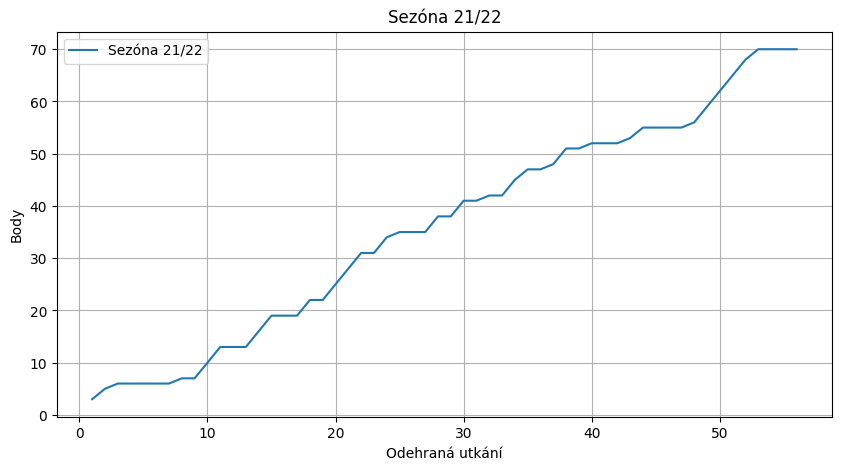

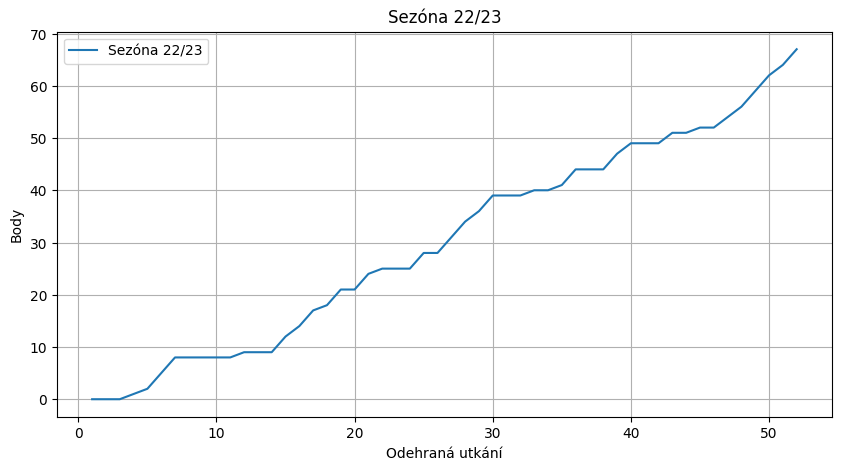

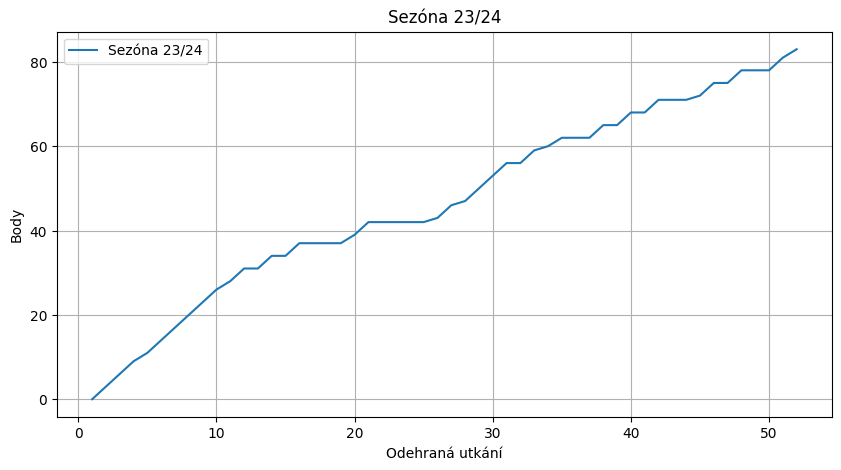

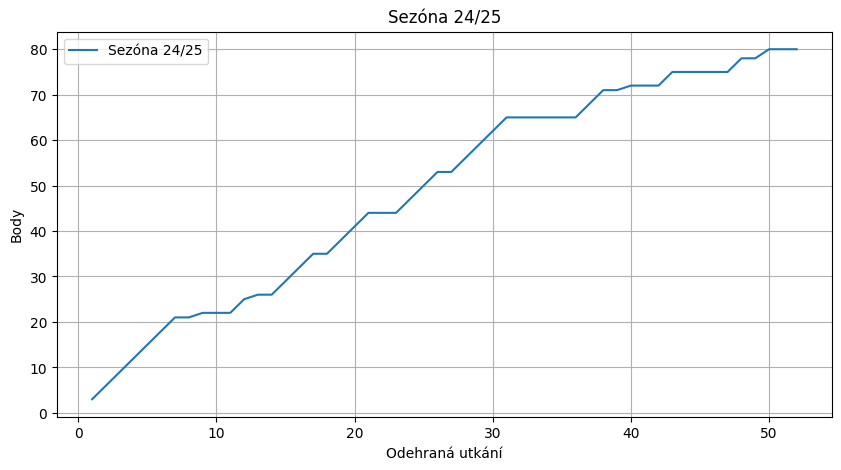

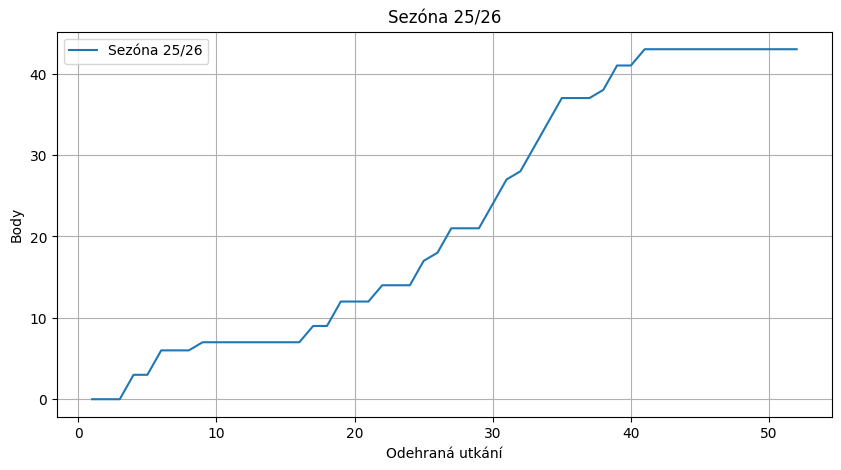

In [37]:
seasons = litvinov_df["Sezóna"].unique().tolist()

for season in seasons:
    choice_season = litvinov_df[litvinov_df["Sezóna"] == season]

    number_matches = choice_season["Odehr. z."].tolist()
    points = choice_season["Bodů celkově"].tolist()

    plt.figure(figsize=(10,5))

    plt.plot(number_matches, points, label=season)

    plt.title(season)
    plt.xlabel("Odehraná utkání")
    plt.ylabel("Body")

    plt.legend()
    plt.grid(True)

    plt.show()

# Comparison of gained points in all seasons from dataset

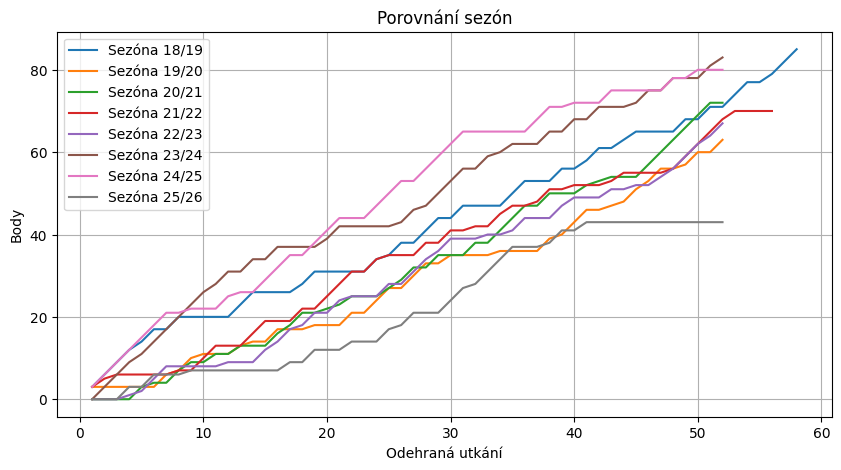

In [38]:
plt.figure(figsize=(10,5))
seasons = litvinov_df["Sezóna"].unique().tolist()
for season in seasons:
    choice_season = litvinov_df[litvinov_df["Sezóna"] == season]

    plt.plot(
        choice_season["Odehr. z."],
        choice_season["Bodů celkově"],
        label=season
    )

plt.title("Porovnání sezón")
plt.xlabel("Odehraná utkání")
plt.ylabel("Body")
plt.legend()
plt.grid(True)
plt.savefig("pic.png")
plt.show()

# Comparing of points in all seasons - it is not so readable picture due to many seasons

In [42]:
chosen_type_match = "předkolo"
first_round_playoff = litvinov_df.loc[(litvinov_df["Kolo"] == chosen_type_match)][["Sezóna", "Kolo", "Soupeř", "Doma/venku", "Výsledek pro LIT", "Výsledek"]]
first_round_playoff
# Which round to print - playoff ("předkolo", "čtvrtfinále" or "semifinále"), playout, "baráž" or round 1 to 60)

,Sezóna,Kolo,Soupeř,Doma/venku,Výsledek pro LIT,Výsledek
Datum,,,,,,
2021-03-10,Sezóna 20/21,předkolo,Mountfield HK,V,0:2,P
2021-03-11,Sezóna 20/21,předkolo,Mountfield HK,V,1:3,P
2021-03-13,Sezóna 20/21,předkolo,Mountfield HK,D,1:5,P
2023-03-08,Sezóna 22/23,předkolo,Třinec,V,1:3,P
2023-03-09,Sezóna 22/23,předkolo,Třinec,V,4:5pp,PP
2023-03-11,Sezóna 22/23,předkolo,Třinec,D,2:4,P
2024-03-06,Sezóna 23/24,předkolo,Plzeň,D,4:2,V
2024-03-07,Sezóna 23/24,předkolo,Plzeň,D,4:1,V
2024-03-09,Sezóna 23/24,předkolo,Plzeň,V,2:1pp,VP


In [91]:
playoff_round = "předkolo", "čtvrtfinále", "semifinále", "finále"
litvinov_playoff = litvinov_df.loc[litvinov_df["Kolo"].isin(playoff_round)][["Sezóna", "Kolo", "Soupeř", "Doma/venku", "Výsledek pro LIT", "Výsledek", "Góly v přesilovce", "Góly v oslabení", "Góly inkas. v přesilovce", "Góly inkas. v oslabení"]]
litvinov_playoff
# Every playoff matches

,Sezóna,Kolo,Soupeř,Doma/venku,Výsledek pro LIT,Výsledek,Góly v přesilovce,Góly v oslabení,Góly inkas. v přesilovce,Góly inkas. v oslabení
Datum,,,,,,,,,,
2021-03-10,Sezóna 20/21,předkolo,Mountfield HK,V,0:2,P,0,0,0,1
2021-03-11,Sezóna 20/21,předkolo,Mountfield HK,V,1:3,P,1,0,0,1
2021-03-13,Sezóna 20/21,předkolo,Mountfield HK,D,1:5,P,0,0,0,1
2023-03-08,Sezóna 22/23,předkolo,Třinec,V,1:3,P,0,0,0,0
2023-03-09,Sezóna 22/23,předkolo,Třinec,V,4:5pp,PP,3,0,0,2
2023-03-11,Sezóna 22/23,předkolo,Třinec,D,2:4,P,0,0,0,1
2024-03-06,Sezóna 23/24,předkolo,Plzeň,D,4:2,V,1,0,0,1
2024-03-07,Sezóna 23/24,předkolo,Plzeň,D,4:1,V,1,0,0,0
2024-03-09,Sezóna 23/24,předkolo,Plzeň,V,2:1pp,VP,1,0,0,0


In [92]:
performance_playoff = litvinov_playoff.groupby("Výsledek")["Kolo"].count().sort_values(ascending=False)
performance_playoff
# Results in playoff (total)

Výsledek
P     14
V      4
VP     4
PP     1
Name: Kolo, dtype: int64

In [93]:
performance_playoff = litvinov_playoff.groupby(["Výsledek", "Doma/venku"])["Kolo"].count().sort_values(ascending=False).unstack(fill_value=0)
performance_playoff
# Results in playoff (Home x Away)

Doma/venku,D,V
Výsledek,,
P,7,7
PP,0,1
V,3,1
VP,1,3


## Statistics against each opponents

- Matches against each opponent (you can choose opponent)
- Results against chosen opponent
- Comparison of number of wins against each opponents
- Powerplay and shorthanded goals against each opponents

In [29]:
chosen_matches = litvinov_df[litvinov_df["Soupeř"] == "Pardubice"].sort_values("Datum", ascending=False)
chosen_matches[["Sezóna", "Kolo", "Doma/venku", "Výsledek pro LIT", "Góly v přesilovce", "Body v zápase"]]
# Printing of all Litvínov´s matches results according to selected opponent (opponent from list of opponents above)

,Sezóna,Kolo,Doma/venku,Výsledek pro LIT,Góly v přesilovce,Body v zápase
Datum,,,,,,
2026-02-27,Sezóna 25/26,49,D,1:4,1,0.0
2025-12-30,Sezóna 25/26,36,V,2:3,0,0.0
2025-11-16,Sezóna 25/26,23,D,1:4,0,0.0
2025-09-30,Sezóna 25/26,10,V,1:2pp,0,1.0
2025-02-21,Sezóna 24/25,47,D,2:5,1,0.0
2025-01-16,Sezóna 24/25,34,V,1:3,0,0.0
2024-11-22,Sezóna 24/25,21,D,4:1,1,3.0
2024-10-04,Sezóna 24/25,8,V,1:3,0,0.0
2024-04-05,Sezóna 23/24,semifinále,D,5:6,2,NaN


In [43]:
chosen_opponent_place = litvinov_df[(litvinov_df["Soupeř"] == "Plzeň") & (litvinov_df["Doma/venku"] == "V")].sort_values("Datum", ascending=False)
chosen_opponent_place[["Sezóna", "Kolo", "Doma/venku", "Výsledek pro LIT", "Góly v přesilovce", "Body v zápase"]]
# Printing of all Litvínov´s matches results according to selected opponent home x away (opponent from list of opponents above)


,Sezóna,Kolo,Doma/venku,Výsledek pro LIT,Góly v přesilovce,Body v zápase
Datum,,,,,,
2026-03-01,Sezóna 25/26,50,V,2:3,1,0
2025-11-20,Sezóna 25/26,24,V,2:7,0,0
2024-12-22,Sezóna 24/25,28,V,2:1,1,3
2024-09-20,Sezóna 24/25,2,V,3:1,0,3
2024-03-09,Sezóna 23/24,předkolo,V,2:1pp,1,<NA>
2024-01-28,Sezóna 23/24,41,V,5:3,1,3
2023-10-29,Sezóna 23/24,15,V,2:5,0,0
2023-01-13,Sezóna 22/23,37,V,1:4,0,0
2022-10-16,Sezóna 22/23,11,V,3:4,2,0


In [59]:
choose_opponent = "Sparta"
result_count_opp = litvinov_df[(litvinov_df["Soupeř"] == choose_opponent)].groupby("Výsledek pro LIT")["Kolo"].count().sort_values(ascending=False)
result_count_opp
# Numerosity of results against chosen opponent (total)

Výsledek pro LIT
1:3      3
1:5      3
3:5      3
3:2      2
4:2      2
2:3      2
3:4pp    1
4:8      1
4:6      1
4:5pp    1
4:0      1
3:8      1
3:6      1
0:2      1
3:2sn    1
0:3      1
2:4      1
2:1      1
1:4      1
1:2      1
0:5      1
0:4      1
5:2      1
Name: Kolo, dtype: int64

In [60]:
choose_opponent = "Sparta"
result_count_opp = litvinov_df[(litvinov_df["Soupeř"] == choose_opponent)].groupby(["Doma/venku", "Výsledek pro LIT"])["Kolo"].count().unstack(fill_value=0)
result_count_opp
# Numerosity of results against chosen opponent (Home x Away)

Výsledek pro LIT,0:2,0:3,0:4,0:5,1:2,1:3,1:4,1:5,2:1,2:3,...,3:4pp,3:5,3:6,3:8,4:0,4:2,4:5pp,4:6,4:8,5:2
Doma/venku,,,,,,,,,,,,,,,,,,,,,
D,1,0,1,1,0,1,1,1,0,0,...,1,1,0,1,1,1,0,0,0,1
Open air Dresden,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
V,0,1,0,0,1,2,0,2,1,1,...,0,2,1,0,0,1,1,1,1,0


In [ ]:
choose_opponent = "Sparta"
result_count_opp = litvinov_df[(litvinov_df["Soupeř"] == choose_opponent)].groupby("Výsledek")["Kolo"].count().sort_values(ascending=False)
result_count_opp
# Count of results against chosen opponent

Výsledek
P     22
V      7
PP     2
VP     1
Name: Kolo, dtype: int64

In [61]:
choose_opponent = "Sparta"
result_count_opp = (litvinov_df[litvinov_df["Soupeř"] == choose_opponent].groupby(["Doma/venku", "Výsledek"])["Kolo"].count().unstack(fill_value=0))
result_count_opp
# Count of results against chosen opponent Home x Away

Výsledek,P,PP,V,VP
Doma/venku,,,,
D,9,1,5,0
Open air Dresden,1,0,0,0
V,12,1,2,1


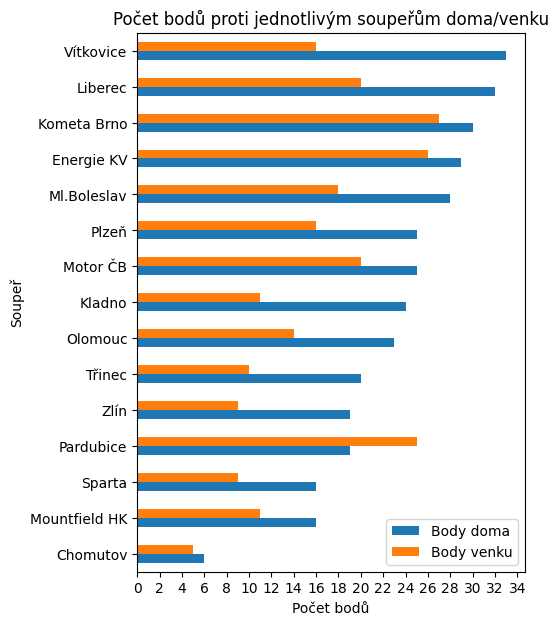

In [116]:
from matplotlib.ticker import MultipleLocator
points_home = litvinov_df[litvinov_df["Doma/venku"] == "D"].groupby("Soupeř")["Body v zápase"].sum()
points_away = litvinov_df[litvinov_df["Doma/venku"] == "V"].groupby("Soupeř")["Body v zápase"].sum()
points = pd.concat([points_home, points_away], axis=1)
points.columns = ["Body doma", "Body venku"]

points.sort_values("Body doma").plot(kind="barh", figsize=(5, 7))
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(2))

plt.title("Počet bodů proti jednotlivým soupeřům doma/venku")
plt.xlabel("Počet bodů")
plt.ylabel("Soupeř")
plt.legend()
plt.show()


# Number of points against all opponents Home x Away

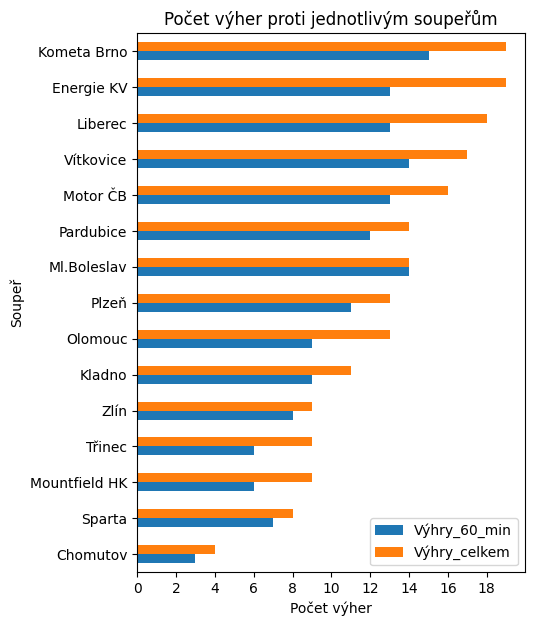

In [66]:
from matplotlib.ticker import MultipleLocator
wins_regular = litvinov_df[litvinov_df["Výsledek"] == "V"].groupby("Soupeř").size()
wins_total = litvinov_df[litvinov_df["Výsledek"].isin(["V", "VP"])].groupby("Soupeř").size()
wins = pd.concat([wins_regular, wins_total], axis=1)
wins.columns = ["Výhry_60_min", "Výhry_celkem"]
wins.sort_values("Výhry_celkem").plot(kind="barh",figsize=(5, 7))
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(2))
plt.title("Počet výher proti jednotlivým soupeřům")
plt.xlabel("Počet výher")
plt.ylabel("Soupeř")
plt.legend()
plt.show()

# Number of regular wins and all wins including wins in overtime

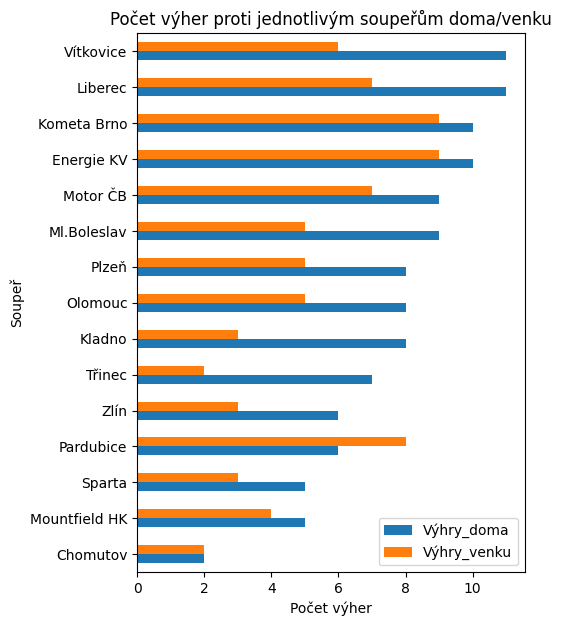

In [ ]:
from matplotlib.ticker import MultipleLocator
wins_home = litvinov_df[(litvinov_df["Výsledek"].isin(["V", "VP"])) & (litvinov_df["Doma/venku"] == "D")].groupby("Soupeř").size()
wins_away = litvinov_df[(litvinov_df["Výsledek"].isin(["V", "VP"])) & (litvinov_df["Doma/venku"] == "V")].groupby("Soupeř").size()

wins = pd.concat([wins_home, wins_away], axis=1)
wins.columns = ["Výhry_doma", "Výhry_venku"]
wins.sort_values("Výhry_doma").plot(kind="barh",figsize=(5, 7))
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(2))
plt.title("Počet výher proti jednotlivým soupeřům doma/venku")
plt.xlabel("Počet výher")
plt.ylabel("Soupeř")
plt.legend()
plt.show()

# Number of all wins including wins in overtime - Home x Away

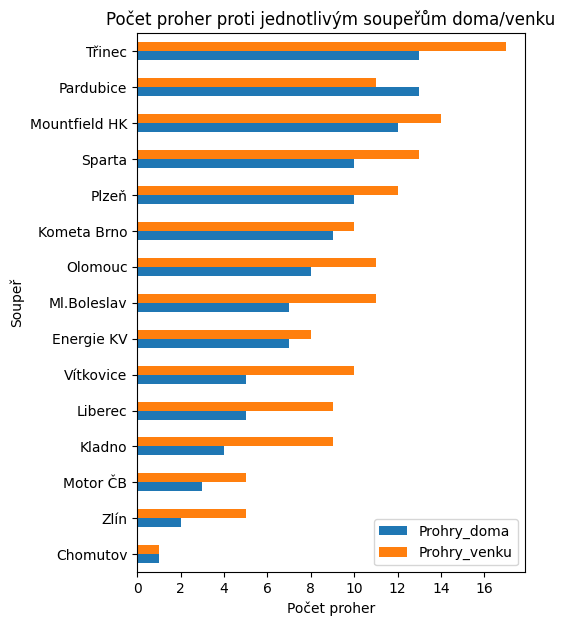

In [69]:
from matplotlib.ticker import MultipleLocator
wins_home = litvinov_df[(litvinov_df["Výsledek"].isin(["P", "PP"])) & (litvinov_df["Doma/venku"] == "D")].groupby("Soupeř").size()
wins_away = litvinov_df[(litvinov_df["Výsledek"].isin(["P", "PP"])) & (litvinov_df["Doma/venku"] == "V")].groupby("Soupeř").size()

wins = pd.concat([wins_home, wins_away], axis=1)
wins.columns = ["Prohry_doma", "Prohry_venku"]
wins.sort_values("Prohry_doma").plot(kind="barh",figsize=(5, 7))
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(2))
plt.title("Počet proher proti jednotlivým soupeřům doma/venku")
plt.xlabel("Počet proher")
plt.ylabel("Soupeř")
plt.legend()
plt.show()

# Number of all losses including losses in overtime - Home x Away

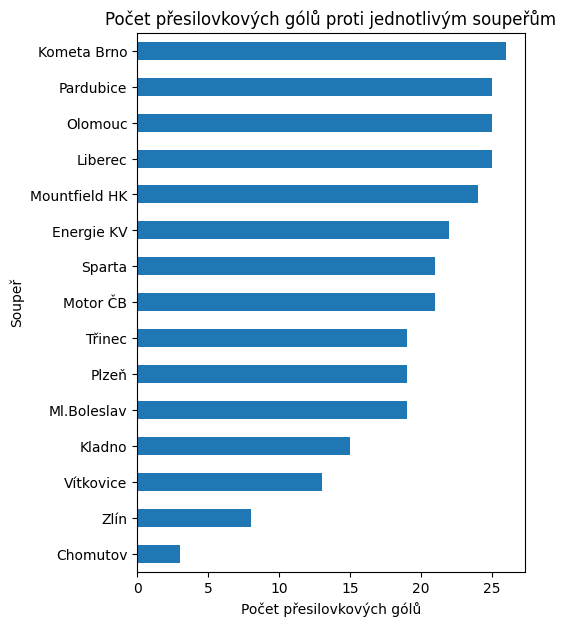

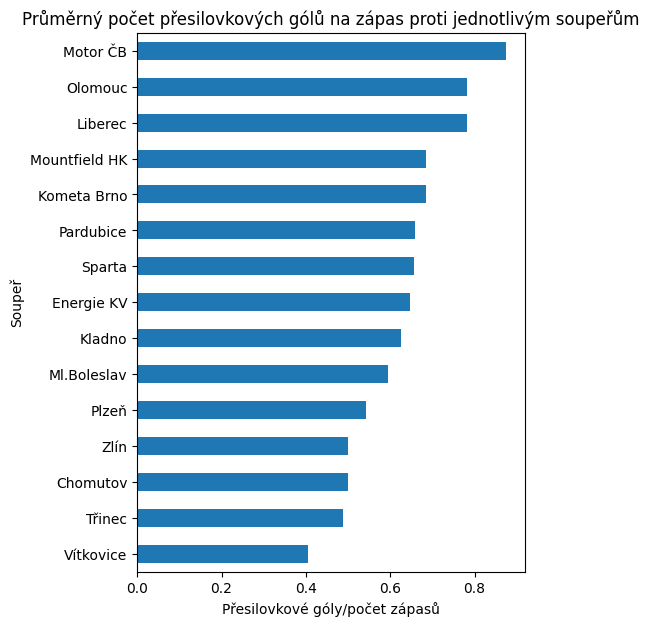

In [65]:
ppg_sum = litvinov_df.groupby("Soupeř")["Góly v přesilovce"].sum()
ppg_avg = litvinov_df.groupby("Soupeř")["Góly v přesilovce"].mean()

plt.figure(figsize=(5, 7))
ppg_sum.sort_values().plot(kind="barh")

plt.title("Počet přesilovkových gólů proti jednotlivým soupeřům")
plt.xlabel("Počet přesilovkových gólů")
plt.ylabel("Soupeř")
plt.show()

plt.figure(figsize=(5, 7))
ppg_avg.sort_values().plot(kind="barh")
plt.title("Průměrný počet přesilovkových gólů na zápas proti jednotlivým soupeřům")
plt.xlabel("Přesilovkové góly/počet zápasů")
plt.ylabel("Soupeř")
plt.show()


# Number of powerplay goals against all opponents and powerplay goals / matches count.

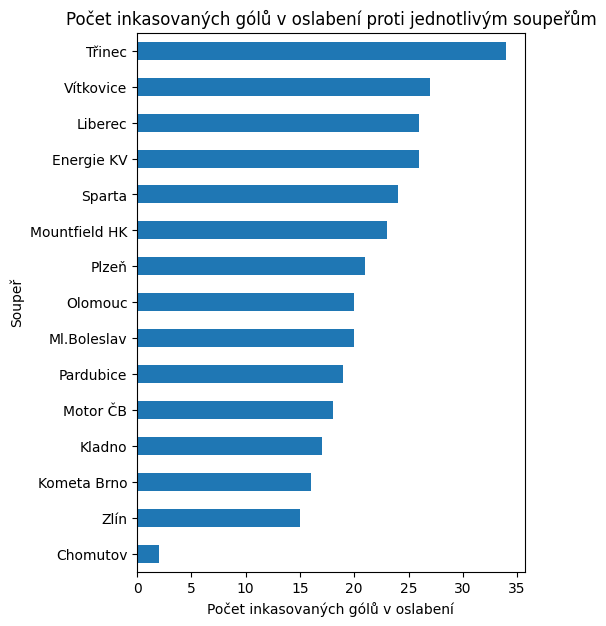

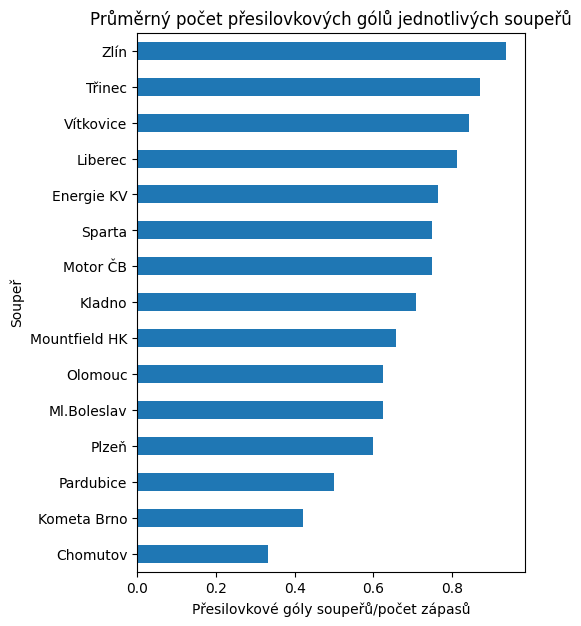

In [ ]:
ppg_sum = litvinov_df.groupby("Soupeř")["Góly inkas. v oslabení"].sum()
ppg_avg = litvinov_df.groupby("Soupeř")["Góly inkas. v oslabení"].mean()

plt.figure(figsize=(5, 7))
ppg_sum.sort_values().plot(kind="barh")

plt.title("Počet inkasovaných gólů v oslabení proti jednotlivým soupeřům")
plt.xlabel("Počet inkasovaných gólů v oslabení")
plt.ylabel("Soupeř")
plt.show()

plt.figure(figsize=(5, 7))
ppg_avg.sort_values().plot(kind="barh")
plt.title("Průměrný počet přesilovkových gólů jednotlivých soupeřů")
plt.xlabel("Přesilovkové góly soupeřů/počet zápasů")
plt.ylabel("Soupeř")
plt.show()

# Number of powerplay goals of Litvínov´s opponents against Litvínov and powerplay goals / matches count.

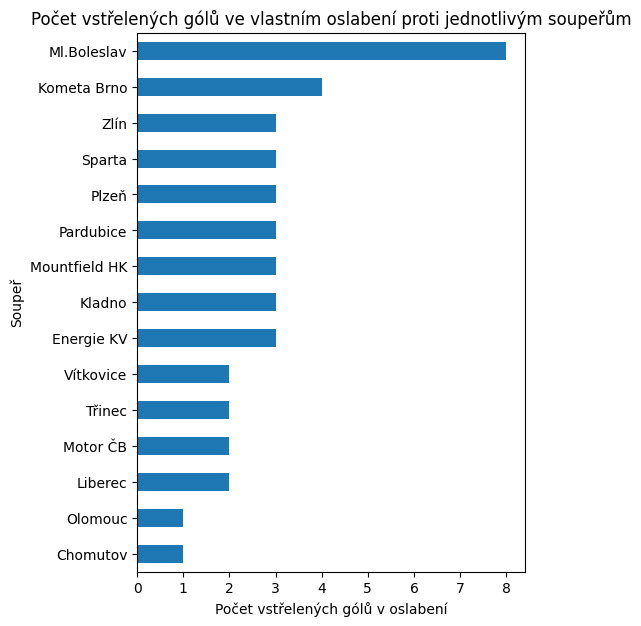

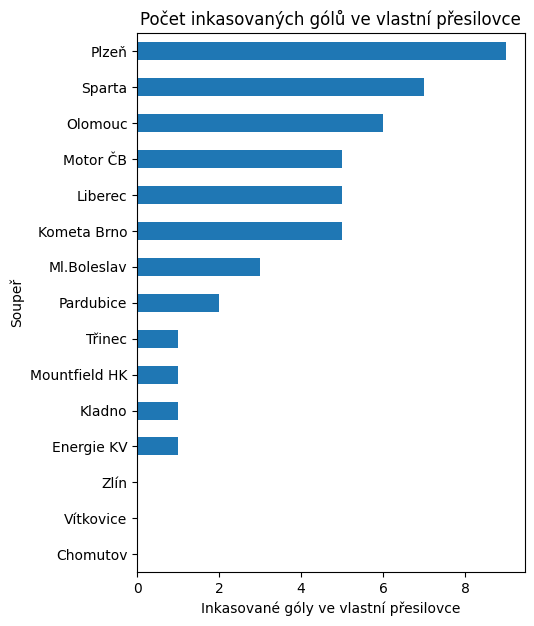

In [72]:
ppg_sum = litvinov_df.groupby("Soupeř")["Góly v oslabení"].sum()
ppg_avg = litvinov_df.groupby("Soupeř")["Góly inkas. v přesilovce"].sum()

plt.figure(figsize=(5, 7))
ppg_sum.sort_values().plot(kind="barh")

plt.title("Počet vstřelených gólů ve vlastním oslabení proti jednotlivým soupeřům")
plt.xlabel("Počet vstřelených gólů v oslabení")
plt.ylabel("Soupeř")
plt.show()

plt.figure(figsize=(5, 7))
ppg_avg.sort_values().plot(kind="barh")
plt.title("Počet inkasovaných gólů ve vlastní přesilovce")
plt.xlabel("Inkasované góly ve vlastní přesilovce")
plt.ylabel("Soupeř")
plt.show()

# Number of shorthanded goals versus number of conceded goals in own powerplay.

## Hockey Statistics - shooting goals

In [73]:
scorer_cols = [col for col in litvinov_df.columns if "střelec" in col]

scorers = (
    litvinov_df[scorer_cols]
    .stack()
    .dropna()
    .tolist()
)
scorers
# List of all Litvínovs scorers

['František GERHÁT',
 'David TŮMA',
 'Juraj MIKÚŠ',
 'Karel KUBÁT',
 'Karel KUBÁT',
 'Tomáš MATOUŠEK',
 'Viktor HÜBL',
 'Juraj MIKÚŠ',
 'David TŮMA',
 'Jan MYŠÁK',
 'Jan ŠČOTKA',
 'Jan ŠČOTKA',
 'František LUKEŠ',
 'Juraj MIKÚŠ',
 'František GERHÁT',
 'František LUKEŠ',
 'Viktor HÜBL',
 'František LUKEŠ',
 'David TŮMA',
 'Jan MYŠÁK',
 'Jakub PETRUŽÁLEK',
 'Michal TRÁVNÍČEK',
 'Viktor HÜBL',
 'Jan ŠČOTKA',
 'František LUKEŠ',
 'František LUKEŠ',
 'Viktor HÜBL',
 'Jakub ČERNÝ',
 'Michal TRÁVNÍČEK',
 'František LUKEŠ',
 'Martin HANZL',
 'Viktor HÜBL',
 'Michal TRÁVNÍČEK',
 'Jakub PETRUŽÁLEK',
 'Martin HANZL',
 'Lukáš VÁLEK',
 'Michal TRÁVNÍČEK',
 'Michal TRÁVNÍČEK',
 'Juraj MIKÚŠ',
 'František GERHÁT',
 'Lukáš VÁLEK',
 'Michal TRÁVNÍČEK',
 'Jakub PETRUŽÁLEK',
 'Viktor HÜBL',
 'Juraj MIKÚŠ',
 'Ondřej JURČÍK',
 'Lukáš VÁLEK',
 'Mathias PORSELAND',
 'Jiří HUNKES',
 'Lukáš VÁLEK',
 'Lukáš VÁLEK',
 'Lukáš VÁLEK',
 'František LUKEŠ',
 'Lukáš VÁLEK',
 'František LUKEŠ',
 'Lukáš KAŠPAR',
 'Jan ŠČ

In [74]:
scoring_cols = [col for col in litvinov_df.columns if "střelec" in col]
long_df = (
    litvinov_df[["Soupeř"] + scoring_cols]
    .set_index("Soupeř")
    .stack()
    .reset_index(level=1, drop=True)
    .reset_index(name="Střelec")
)

goals_by_player = (
    long_df
    .groupby(["Soupeř", "Střelec"])
    .size()
    .reset_index(name="Počet_gólů")
)

goals_by_player.sort_values(["Počet_gólů"], ascending=False)
# Scorers against each opponent and number of goals against them


,Soupeř,Střelec,Počet_gólů
127,Kometa Brno,Viktor HÜBL,11
91,Kometa Brno,David KAŠE,10
236,Motor ČB,Patrik ZDRÁHAL,9
52,Energie KV,Richard JARŮŠEK,8
470,Třinec,Nicolas HLAVA,8
...,...,...,...
257,Mountfield HK,Kevin CZUCZMAN,1
256,Mountfield HK,Juraj MIKÚŠ,1
255,Mountfield HK,Josef JÍCHA,1
254,Mountfield HK,Jan ŠČOTKA,1


In [75]:
top_by_opponent = (
    goals_by_player
    .sort_values(["Počet_gólů"], ascending=False)
    .groupby("Soupeř")
    .head(1)
)

top_by_opponent
# Best scorers against each opponent

,Soupeř,Střelec,Počet_gólů
127,Kometa Brno,Viktor HÜBL,11
236,Motor ČB,Patrik ZDRÁHAL,9
52,Energie KV,Richard JARŮŠEK,8
470,Třinec,Nicolas HLAVA,8
303,Olomouc,Nicolas HLAVA,8
337,Pardubice,Martin HANZL,7
403,Plzeň,Petr KOBLASA,7
408,Sparta,Andrej KUDRNA,7
194,Ml.Boleslav,Nicolas HLAVA,7
154,Liberec,Ondřej JURČÍK,5


In [76]:
player = goals_by_player[goals_by_player["Střelec"] == "Jan MYŠÁK"].sort_values("Počet_gólů", ascending=False)
player
# Goals of chosen player

,Soupeř,Střelec,Počet_gólů
326,Pardubice,Jan MYŠÁK,5
67,Kladno,Jan MYŠÁK,2
5,Chomutov,Jan MYŠÁK,1
21,Energie KV,Jan MYŠÁK,1
96,Kometa Brno,Jan MYŠÁK,1
287,Olomouc,Jan MYŠÁK,1
414,Sparta,Jan MYŠÁK,1
448,Třinec,Jan MYŠÁK,1


In [77]:
pivot = goals_by_player.pivot_table(
    index="Střelec",
    columns="Soupeř",
    values="Počet_gólů",
    aggfunc="sum",
    fill_value=0
).astype(int)
pivot
# pivot table - goals of each players against each opponent

Soupeř,Chomutov,Energie KV,Kladno,Kometa Brno,Liberec,Ml.Boleslav,Motor ČB,Mountfield HK,Olomouc,Pardubice,Plzeň,Sparta,Třinec,Vítkovice,Zlín
Střelec,,,,,,,,,,,,,,,
Aaron IRVING,0,0,1,3,0,5,0,1,2,1,2,3,2,2,0
Adam JÁNOŠÍK,0,0,1,0,0,2,0,1,0,0,0,0,0,1,0
Adam POLÁŠEK,0,0,0,2,1,0,0,0,1,0,0,0,0,1,0
Akim ALIU,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
Andrej KUDRNA,0,4,3,3,2,4,2,2,5,1,3,7,5,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tomáš URBAN,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
Uvis Janis BALINSKIS,0,0,0,3,0,4,1,0,1,2,0,0,0,1,2
Viktor HÜBL,2,6,3,11,3,5,4,5,0,2,2,4,2,3,4


In [38]:
pivot["Sparta"].sort_values(ascending=False).head(15)
# List of 15 scorers against chosen opponent

Střelec
Richard JARŮŠEK     7
Andrej KUDRNA       7
Viktor HÜBL         4
Aaron IRVING        3
Martin HANZL        3
Marek BARÁNEK       3
Nicolas HLAVA       3
Giorgio ESTEPHAN    3
Petr KOBLASA        3
Matúš SUKEĽ         3
František LUKEŠ     2
Maxim ČAJKOVIČ      2
Pawel ZYGMUNT       2
Jan ŠČOTKA          2
Jakub PETRUŽÁLEK    2
Name: Sparta, dtype: int32

## Key Findings

- Litvínov's performance varied across seasons in terms of points gained and league position.
- Some opponents were clearly more favourable than others based on match results and goal statistics.
- Litvínov is not so succesful in playoff.
- Scorer analysis identified players who were especially productive against selected teams.
- The project also produced SQL-ready datasets for further work in PostgreSQL.

## Next Steps

- Add SQL queries as list in PDF
- Create a Power BI dashboard as a future extension